In [1]:
%load_ext autoreload
%autoreload 2
import icechunk
import matplotlib.pyplot as plt
import zarr

from srm import catalog
from srm.downscaling_utils import interpolate_fine_to_coarse_grid, rechunk
from srm.qaqc import (
    disagg_test_calculate_metrics,
)
from srm.utils import open_icechunk
import cartopy.crs as ccrs
from srm.plotting import locations, plot_cdf_by_location
import dask
import cartopy.feature as cfeature

In [2]:
from dask.distributed import Client

## Get data

In [3]:
path_output = (
    "s3://carbonplan-srm/output/production/CESM2-WACCM-ERA5-global.icechunk"
)
var = "pr"
scenario = "historical"
ens = "r3i1p1f1"
branch = "v0.11.0"

In [4]:
client = Client()

In [5]:
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: https://cluster-ijmlx.dask.host/jupyter/proxy/8787/status,
Dashboard: https://cluster-ijmlx.dask.host/jupyter/proxy/8787/status,Workers: 8
Total threads: 64,Total memory: 244.49 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:35685,Workers: 0
Dashboard: https://cluster-ijmlx.dask.host/jupyter/proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:42435,Total threads: 8
Dashboard: https://cluster-ijmlx.dask.host/jupyter/proxy/42311/status,Memory: 30.56 GiB
Nanny: tcp://127.0.0.1:42373,


In [6]:
storage = icechunk.s3_storage(
    bucket="carbonplan-srm",
    prefix="output/production/CESM2-WACCM-ERA5-global.icechunk/",
    region="us-west-2")
repo = icechunk.Repository.open(storage)
print(repo.list_branches())
session = repo.readonly_session(branch=branch)
root = zarr.open_group(session.store, mode="r")
# print(root.tree())

{'v0.11.1', 'v0.10.0', 'v0.11.0', 'v0.8.0', 'main', 'v0.7.0'}


In [7]:
lat_slice = slice(-35, -22)
lon_slice = slice(16, 33)

In [8]:
coarse_debiased = open_icechunk(
    path=path_output,
    branch=branch,
    group="debiased_coarse/" + scenario + "/" + var + "/" + ens,
)[var]
debiased_downscaled = open_icechunk(
    path=path_output,
    branch=branch,
    group=scenario + "/" + var + "/" + ens,
)[var]

In [9]:
gcm = "CESM2-WACCM"
scenario = "historical"  # "historical", "SSP245", "G6-1.5K"
raw = (
    catalog.get(gcm)
    .to_xarray()[scenario][var]
    .sel(ensemble_member='r3i1p1f1')
    .sel(time=slice('1978', '2014'))
)

In [14]:
obs_fine = catalog.get("ERA5").to_xarray()[var]
obs_fine = obs_fine.sel(time=slice('1978', '2014'))

In [15]:
obs_fine_churro = obs_fine.chunk({'lat': 100, 'lon': 100, 'time': 100})

In [16]:
obs_fine_churro.to_zarr('s3://carbonplan-scratch/srm/processed/era5-churro.zarr')

ValueError: Specified Zarr chunks encoding['chunks']=(30, 721, 1440) for variable named 'pr' would overlap multiple Dask chunks. Please check the Dask chunks at position 1 and 2, on axis 0, they are overlapped on the same Zarr chunk in the region slice(None, None, None). Writing this array in parallel with Dask could lead to corrupted data. To resolve this issue, consider one of the following options: - Rechunk the array using `chunk()`. - Modify or delete `encoding['chunks']`. - Set `safe_chunks=False`. - Enable automatic chunks alignment with `align_chunks=True`.

In [11]:
obs_coarse = interpolate_fine_to_coarse_grid(
    da_fine_to_coarsen=obs_fine, da_coarse_grid=coarse_debiased
).compute()

In [12]:
coarse_debiased = rechunk(coarse_debiased, pattern="full_space").persist()

# Compare different steps of the process

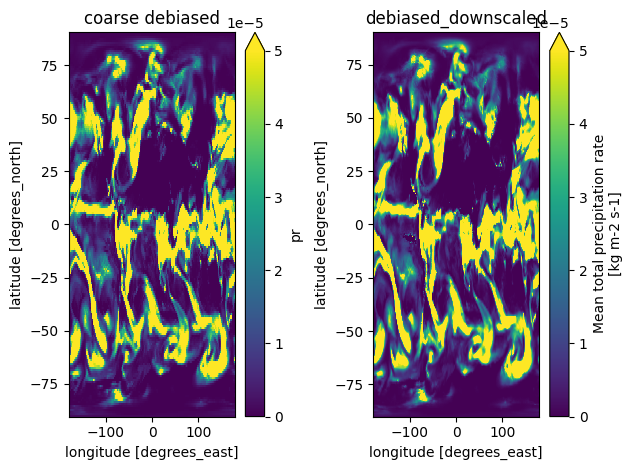

In [15]:
vmax=5e-5
plt.subplot(1, 2, 1)
coarse_debiased.isel(time=0).plot(vmax=vmax)
plt.gca().set_title('coarse debiased')

plt.subplot(1, 2, 2)
debiased_downscaled.isel(time=0).plot(vmax=vmax)
plt.gca().set_title('debiased_downscaled')
plt.tight_layout()

# Do evaluation

In [74]:
# DOY downscaled
debiased_downscaled_doy = debiased_downscaled.groupby("time.dayofyear").mean().compute()

In [75]:
# DOY coarse
coarse_debiased_doy = coarse_debiased.groupby("time.dayofyear").mean().compute()

In [76]:
obs_fine_doy = obs_fine.groupby("time.dayofyear").mean().compute()
obs_coarse_doy = obs_coarse.groupby("time.dayofyear").mean().compute()

In [77]:
mean_obs = obs_fine.mean(dim='time').compute()
mean_downscaled = debiased_downscaled.mean(dim='time').compute()

In [78]:
mean_obs_coarse = obs_coarse.mean(dim='time').compute()
mean_coarse_debiased = coarse_debiased.mean(dim='time').compute()

In [79]:
pbias_fine = ((mean_downscaled-mean_obs)/mean_obs*100).compute()
mae_fine = ((mean_downscaled-mean_obs)).compute()

In [80]:
pbias_coarse = ((mean_coarse_debiased-mean_obs_coarse)/mean_obs_coarse*100).compute()
mae_coarse = ((mean_coarse_debiased-mean_obs_coarse)).compute()

# Evaluate bias in coarse

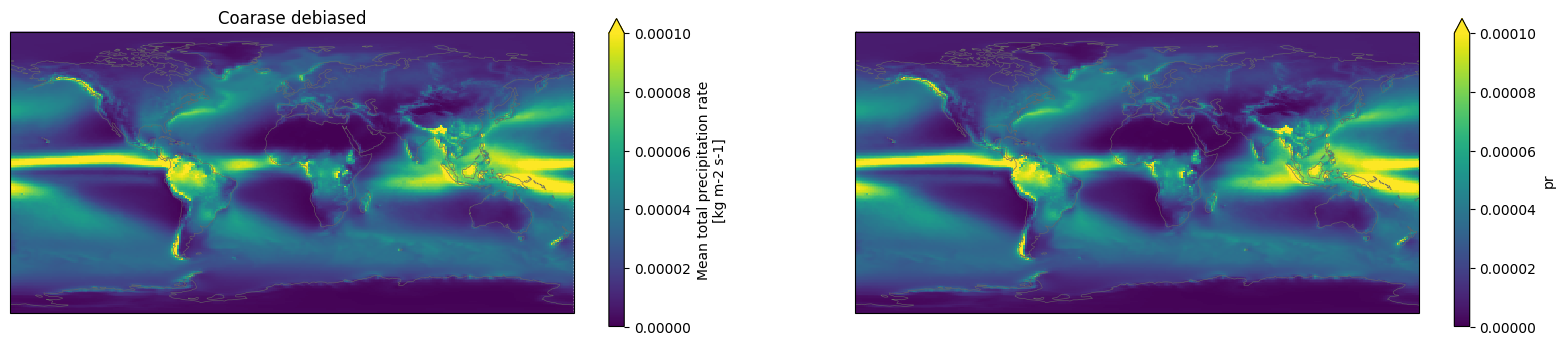

In [64]:
fig, axarr = plt.subplots(1,2, figsize=(20,4), subplot_kw={"projection": ccrs.PlateCarree()})

mean_obs_coarse.plot(ax=axarr[0], cmap='viridis', vmin=0, vmax=1e-4, transform=ccrs.PlateCarree())
axarr[0].set_title('Coarse obs')
mean_coarse_debiased.plot(ax=axarr[1], cmap='viridis', vmin=0, vmax=1e-4, transform=ccrs.PlateCarree())
axarr[0].set_title('Coarase debiased')
for ax in axarr:
    ax.add_feature(cfeature.COASTLINE, linewidth=0.4, edgecolor="0.4")

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(14,8), subplot_kw={"projection": ccrs.PlateCarree()})
ax.add_feature(cfeature.COASTLINE, linewidth=0.4, edgecolor="0.4")
mean_obs_coarse.plot(ax=ax, cmap='viridis', robust=True, transform=ccrs.PlateCarree(), cbar_kwargs={"label": "Bias [%]", "shrink": 0.8})

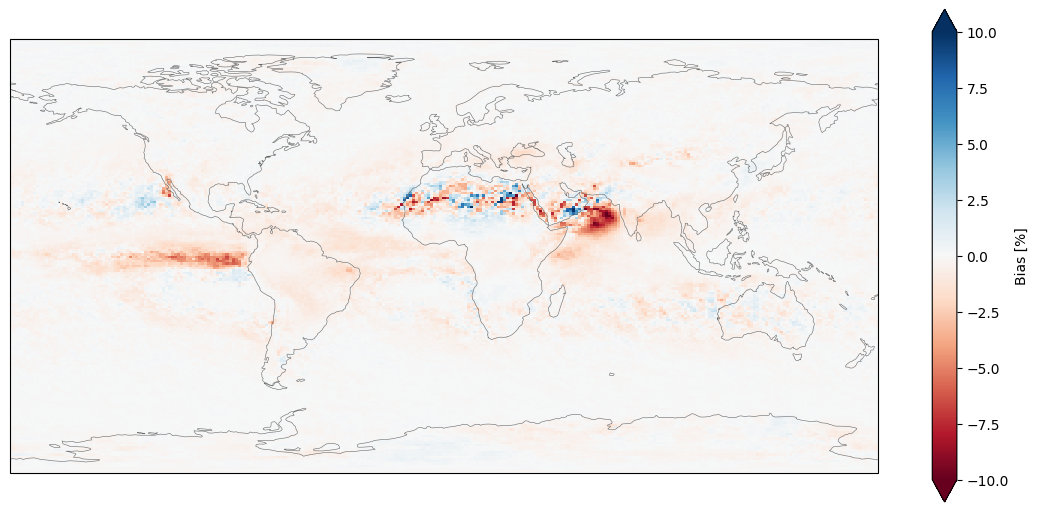

In [44]:
fig, ax = plt.subplots(1,1, figsize=(14,8), subplot_kw={"projection": ccrs.PlateCarree()})
ax.add_feature(cfeature.COASTLINE, linewidth=0.4, edgecolor="0.4")
pbias_coarse.plot(ax=ax, vmin=-10, vmax=10, cmap='RdBu', transform=ccrs.PlateCarree(), cbar_kwargs={"label": "Bias [%]", "shrink": 0.8})

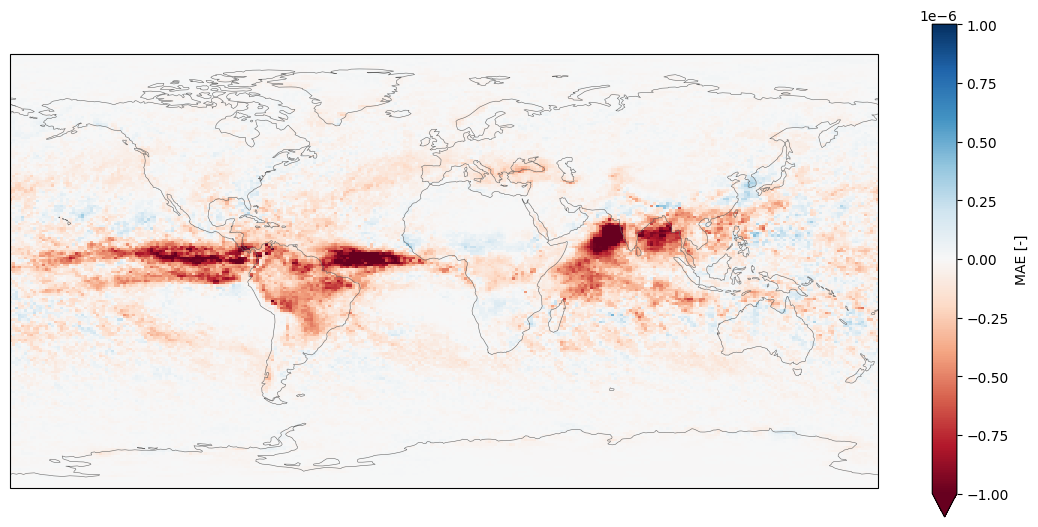

In [45]:
fig, ax = plt.subplots(1,1, figsize=(14,8), subplot_kw={"projection": ccrs.PlateCarree()})
ax.add_feature(cfeature.COASTLINE, linewidth=0.4, edgecolor="0.4")
mae_coarse.plot(vmin=-0.000001, vmax=0.000001, cmap='RdBu', transform=ccrs.PlateCarree(), cbar_kwargs={"label": "MAE [-]", "shrink": 0.8})


In [75]:
# Hot spots of both high MAE and high %bias
hot_spot_high = (pbias_coarse>5)&(mae_coarse>1e-7)

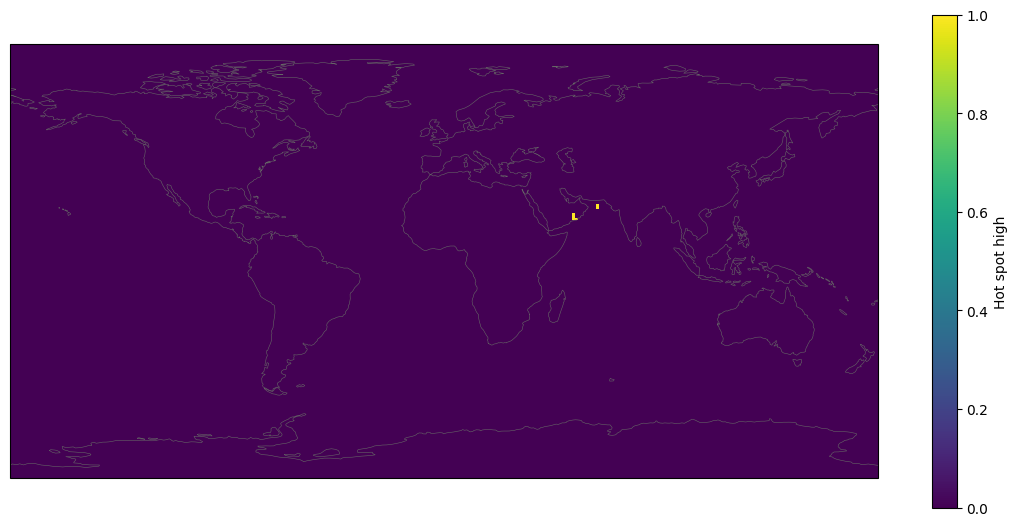

In [76]:
fig, ax = plt.subplots(1,1, figsize=(14,8), subplot_kw={"projection": ccrs.PlateCarree()})
ax.add_feature(cfeature.COASTLINE, linewidth=0.4, edgecolor="0.4")
hot_spot_high.plot(transform=ccrs.PlateCarree(), cbar_kwargs={"label": "Hot spot high", "shrink": 0.8})

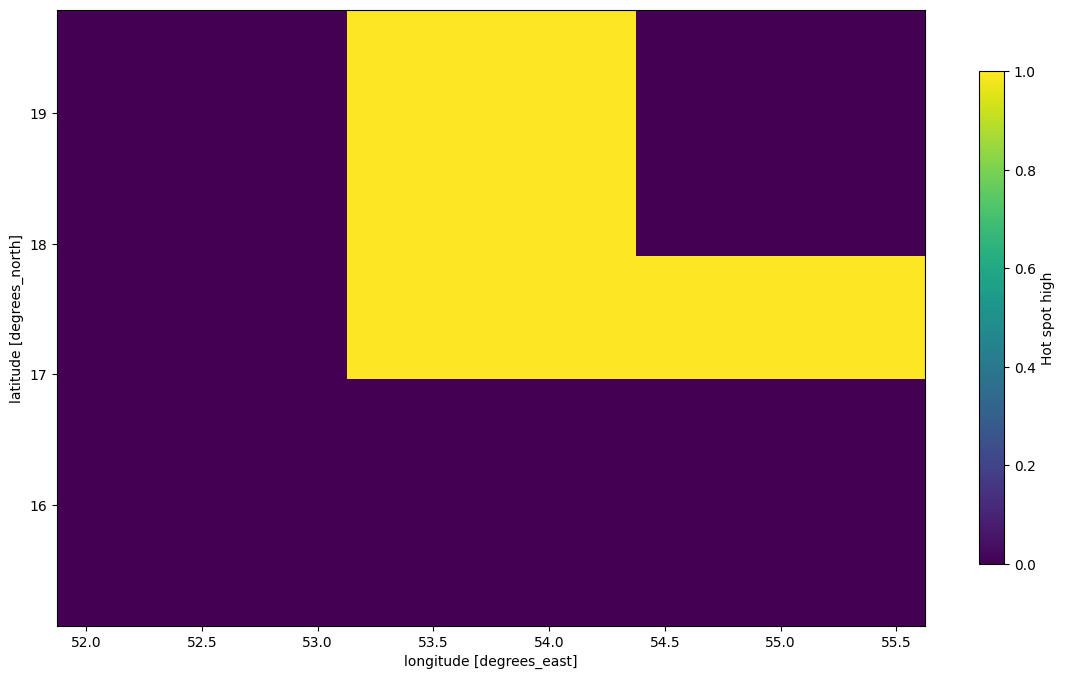

In [87]:
fig, ax = plt.subplots(1,1, figsize=(14,8))
hot_spot_high.sel(lat=slice(15, 20), lon=slice(52,56)).plot(cbar_kwargs={"label": "Hot spot high", "shrink": 0.8})

In [79]:
# Hot spots of both low MAE and low %bias
hot_spot_low = (pbias_coarse<-8)&(mae_coarse<-1e-6)

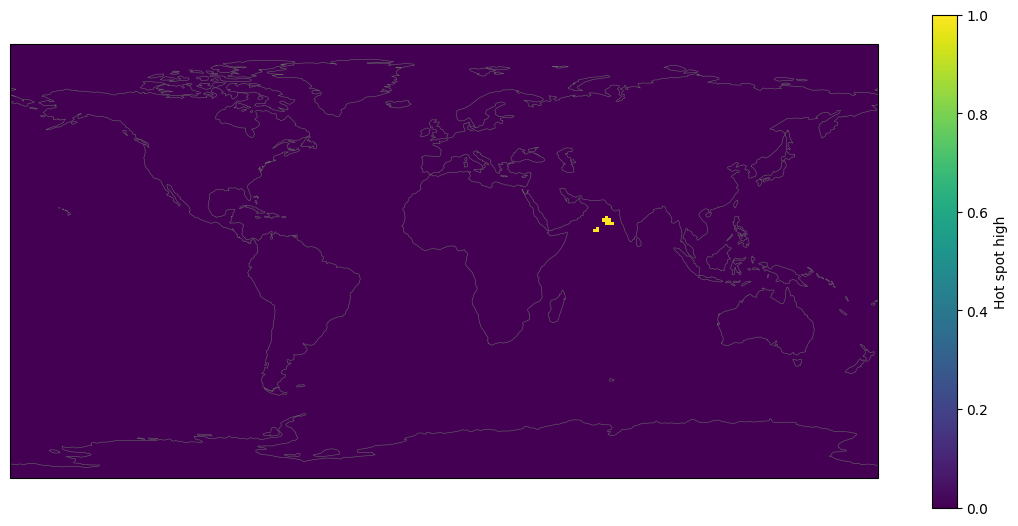

In [80]:
fig, ax = plt.subplots(1,1, figsize=(14,8), subplot_kw={"projection": ccrs.PlateCarree()})
ax.add_feature(cfeature.COASTLINE, linewidth=0.4, edgecolor="0.4")
hot_spot_low.plot(transform=ccrs.PlateCarree(), cbar_kwargs={"label": "Hot spot high", "shrink": 0.8})
plt.xticks()

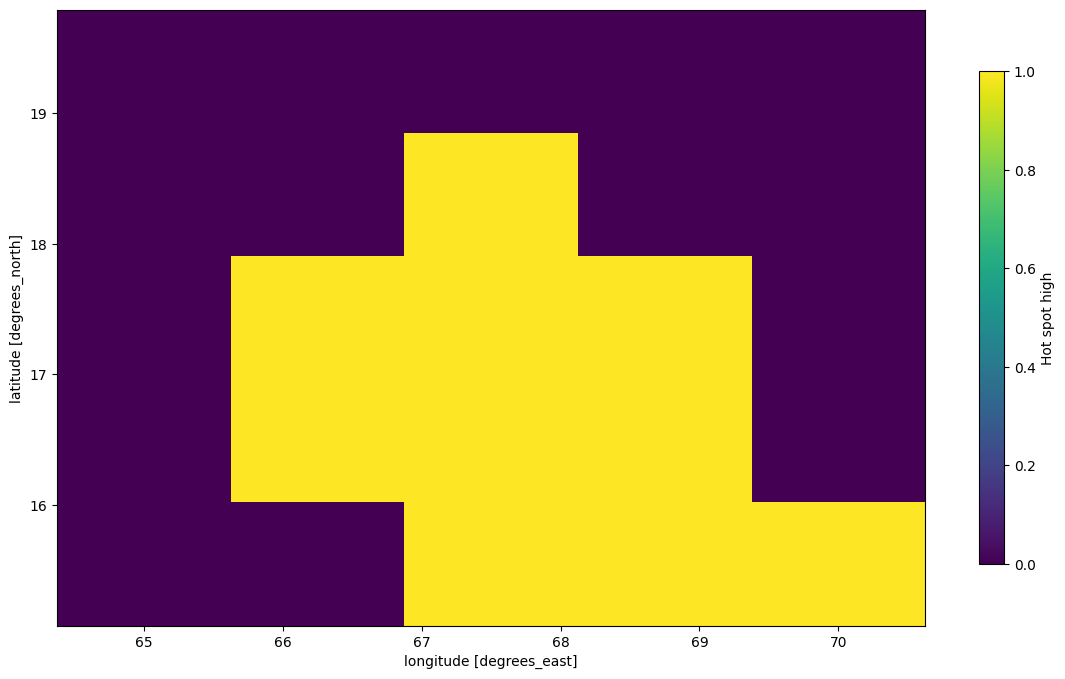

In [91]:
fig, ax = plt.subplots(1,1, figsize=(14,8))
hot_spot_low.sel(lat=slice(15, 20), lon=slice(65,70)).plot(cbar_kwargs={"label": "Hot spot high", "shrink": 0.8})

In [ ]:
# grab pixel ho
hot_spot_coords = {'high': (17, 54),
                   'low': (17, 68)}

# Evaluate bias in fine

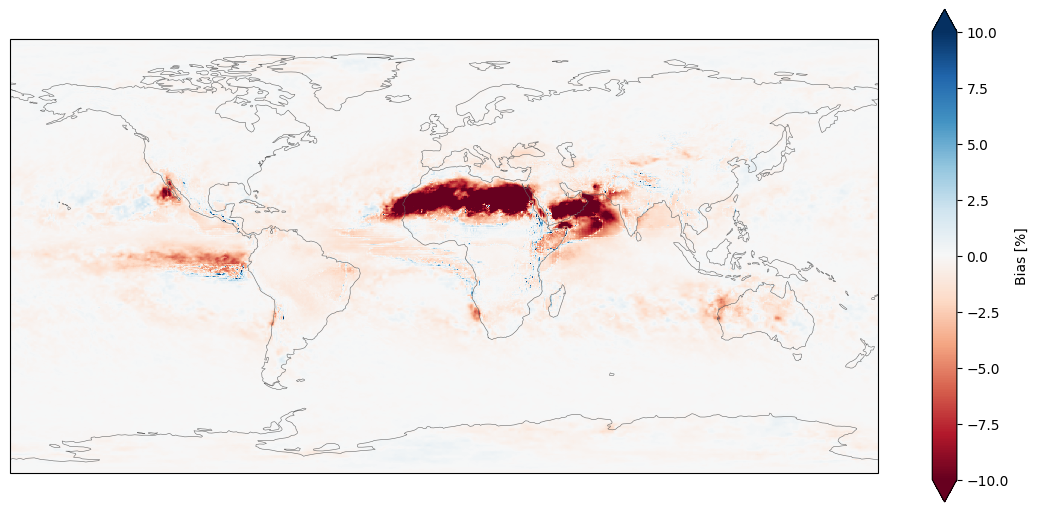

In [81]:
fig, ax = plt.subplots(1,1, figsize=(14,8), subplot_kw={"projection": ccrs.PlateCarree()})
ax.add_feature(cfeature.COASTLINE, linewidth=0.4, edgecolor="0.4")
pbias_fine.plot(ax=ax, vmin=-10, vmax=10, cmap='RdBu', transform=ccrs.PlateCarree(), cbar_kwargs={"label": "Bias [%]", "shrink": 0.8})

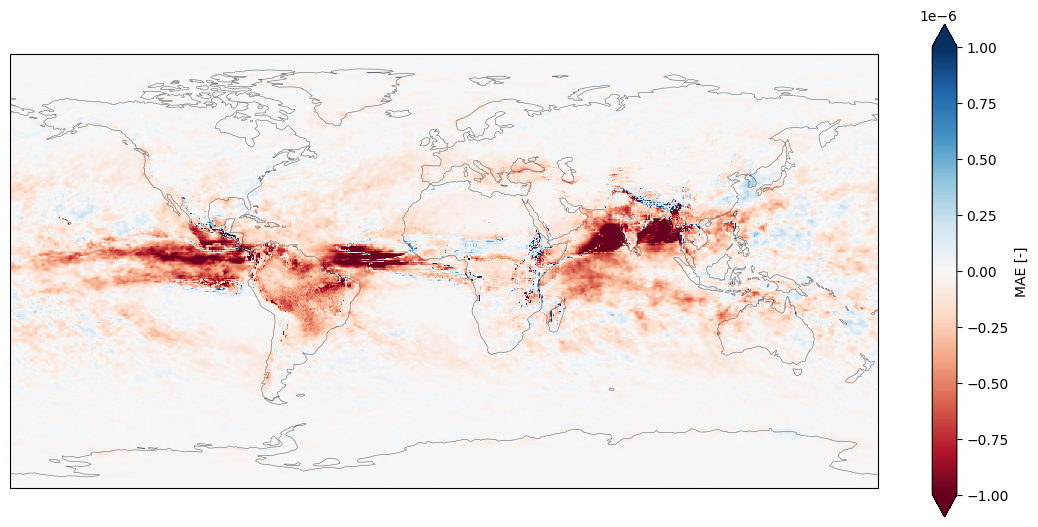

In [82]:
fig, ax = plt.subplots(1,1, figsize=(14,8), subplot_kw={"projection": ccrs.PlateCarree()})
ax.add_feature(cfeature.COASTLINE, linewidth=0.4, edgecolor="0.4")
mae_fine.plot(vmin=-0.000001, vmax=0.000001, cmap='RdBu', transform=ccrs.PlateCarree(), cbar_kwargs={"label": "MAE [-]", "shrink": 0.8})


In [85]:
# Hot spots of both low MAE and low %bias
hot_spot_low = (pbias_fine<-8)&(mae_fine<-1e-6)
hot_spot_high = (pbias_fine>5)&(mae_fine>1e-7)

(array([-200., -150., -100.,  -50.,    0.,   50.,  100.,  150.,  200.]),
 [Text(-200.0, 0, '−200'),
  Text(-150.0, 0, '−150'),
  Text(-100.0, 0, '−100'),
  Text(-50.0, 0, '−50'),
  Text(0.0, 0, '0'),
  Text(50.0, 0, '50'),
  Text(100.0, 0, '100'),
  Text(150.0, 0, '150'),
  Text(200.0, 0, '200')])

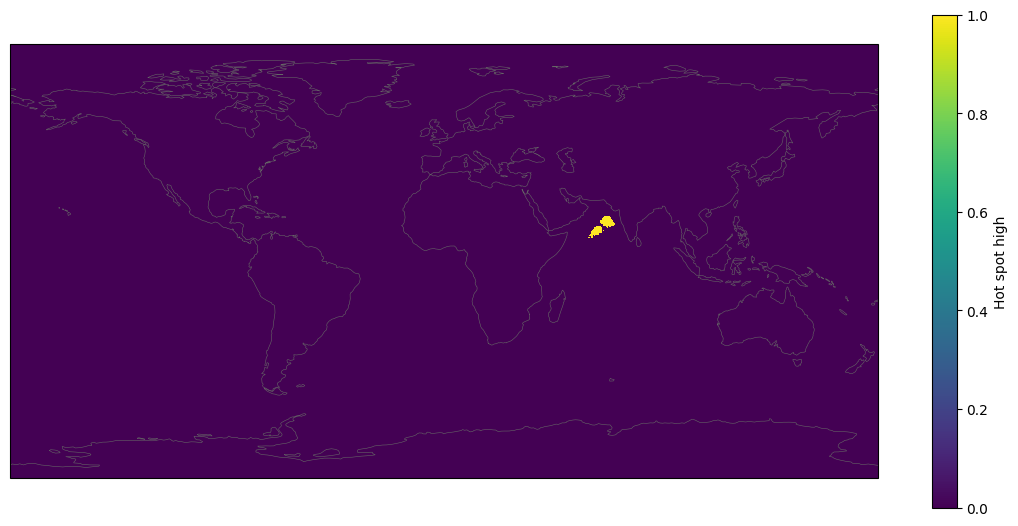

In [84]:
fig, ax = plt.subplots(1,1, figsize=(14,8), subplot_kw={"projection": ccrs.PlateCarree()})
ax.add_feature(cfeature.COASTLINE, linewidth=0.4, edgecolor="0.4")
hot_spot_low.plot(transform=ccrs.PlateCarree(), cbar_kwargs={"label": "Hot spot high", "shrink": 0.8})
plt.xticks()

(array([-200., -150., -100.,  -50.,    0.,   50.,  100.,  150.,  200.]),
 [Text(-200.0, 0, '−200'),
  Text(-150.0, 0, '−150'),
  Text(-100.0, 0, '−100'),
  Text(-50.0, 0, '−50'),
  Text(0.0, 0, '0'),
  Text(50.0, 0, '50'),
  Text(100.0, 0, '100'),
  Text(150.0, 0, '150'),
  Text(200.0, 0, '200')])

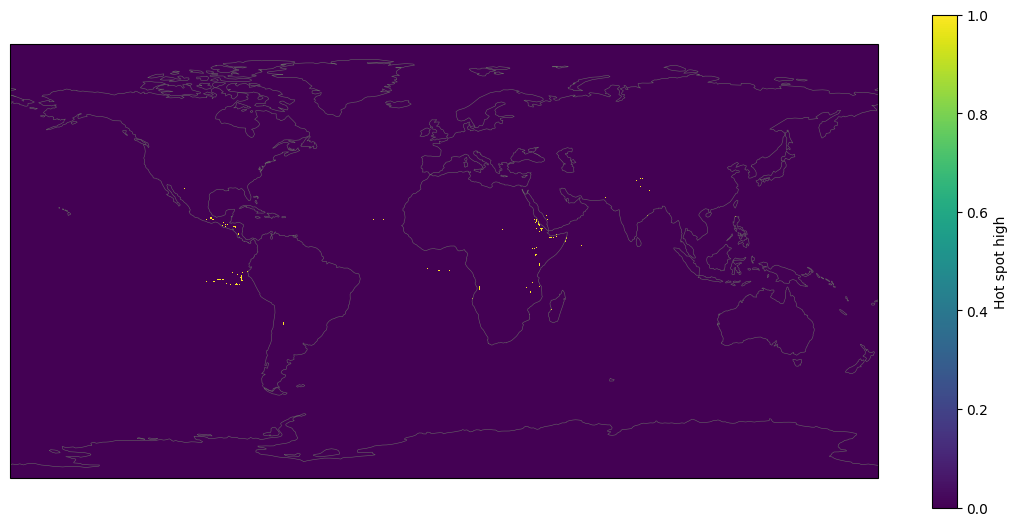

In [86]:
fig, ax = plt.subplots(1,1, figsize=(14,8), subplot_kw={"projection": ccrs.PlateCarree()})
ax.add_feature(cfeature.COASTLINE, linewidth=0.4, edgecolor="0.4")
hot_spot_high.plot(transform=ccrs.PlateCarree(), cbar_kwargs={"label": "Hot spot high", "shrink": 0.8})
plt.xticks()

# CDF comparison across locations


In [70]:
from srm.plotting import locations

In [71]:
locations['High hot spot Oman'] = (17, 54)
locations['Low hot spot Arabian Sea'] = (17, 68)

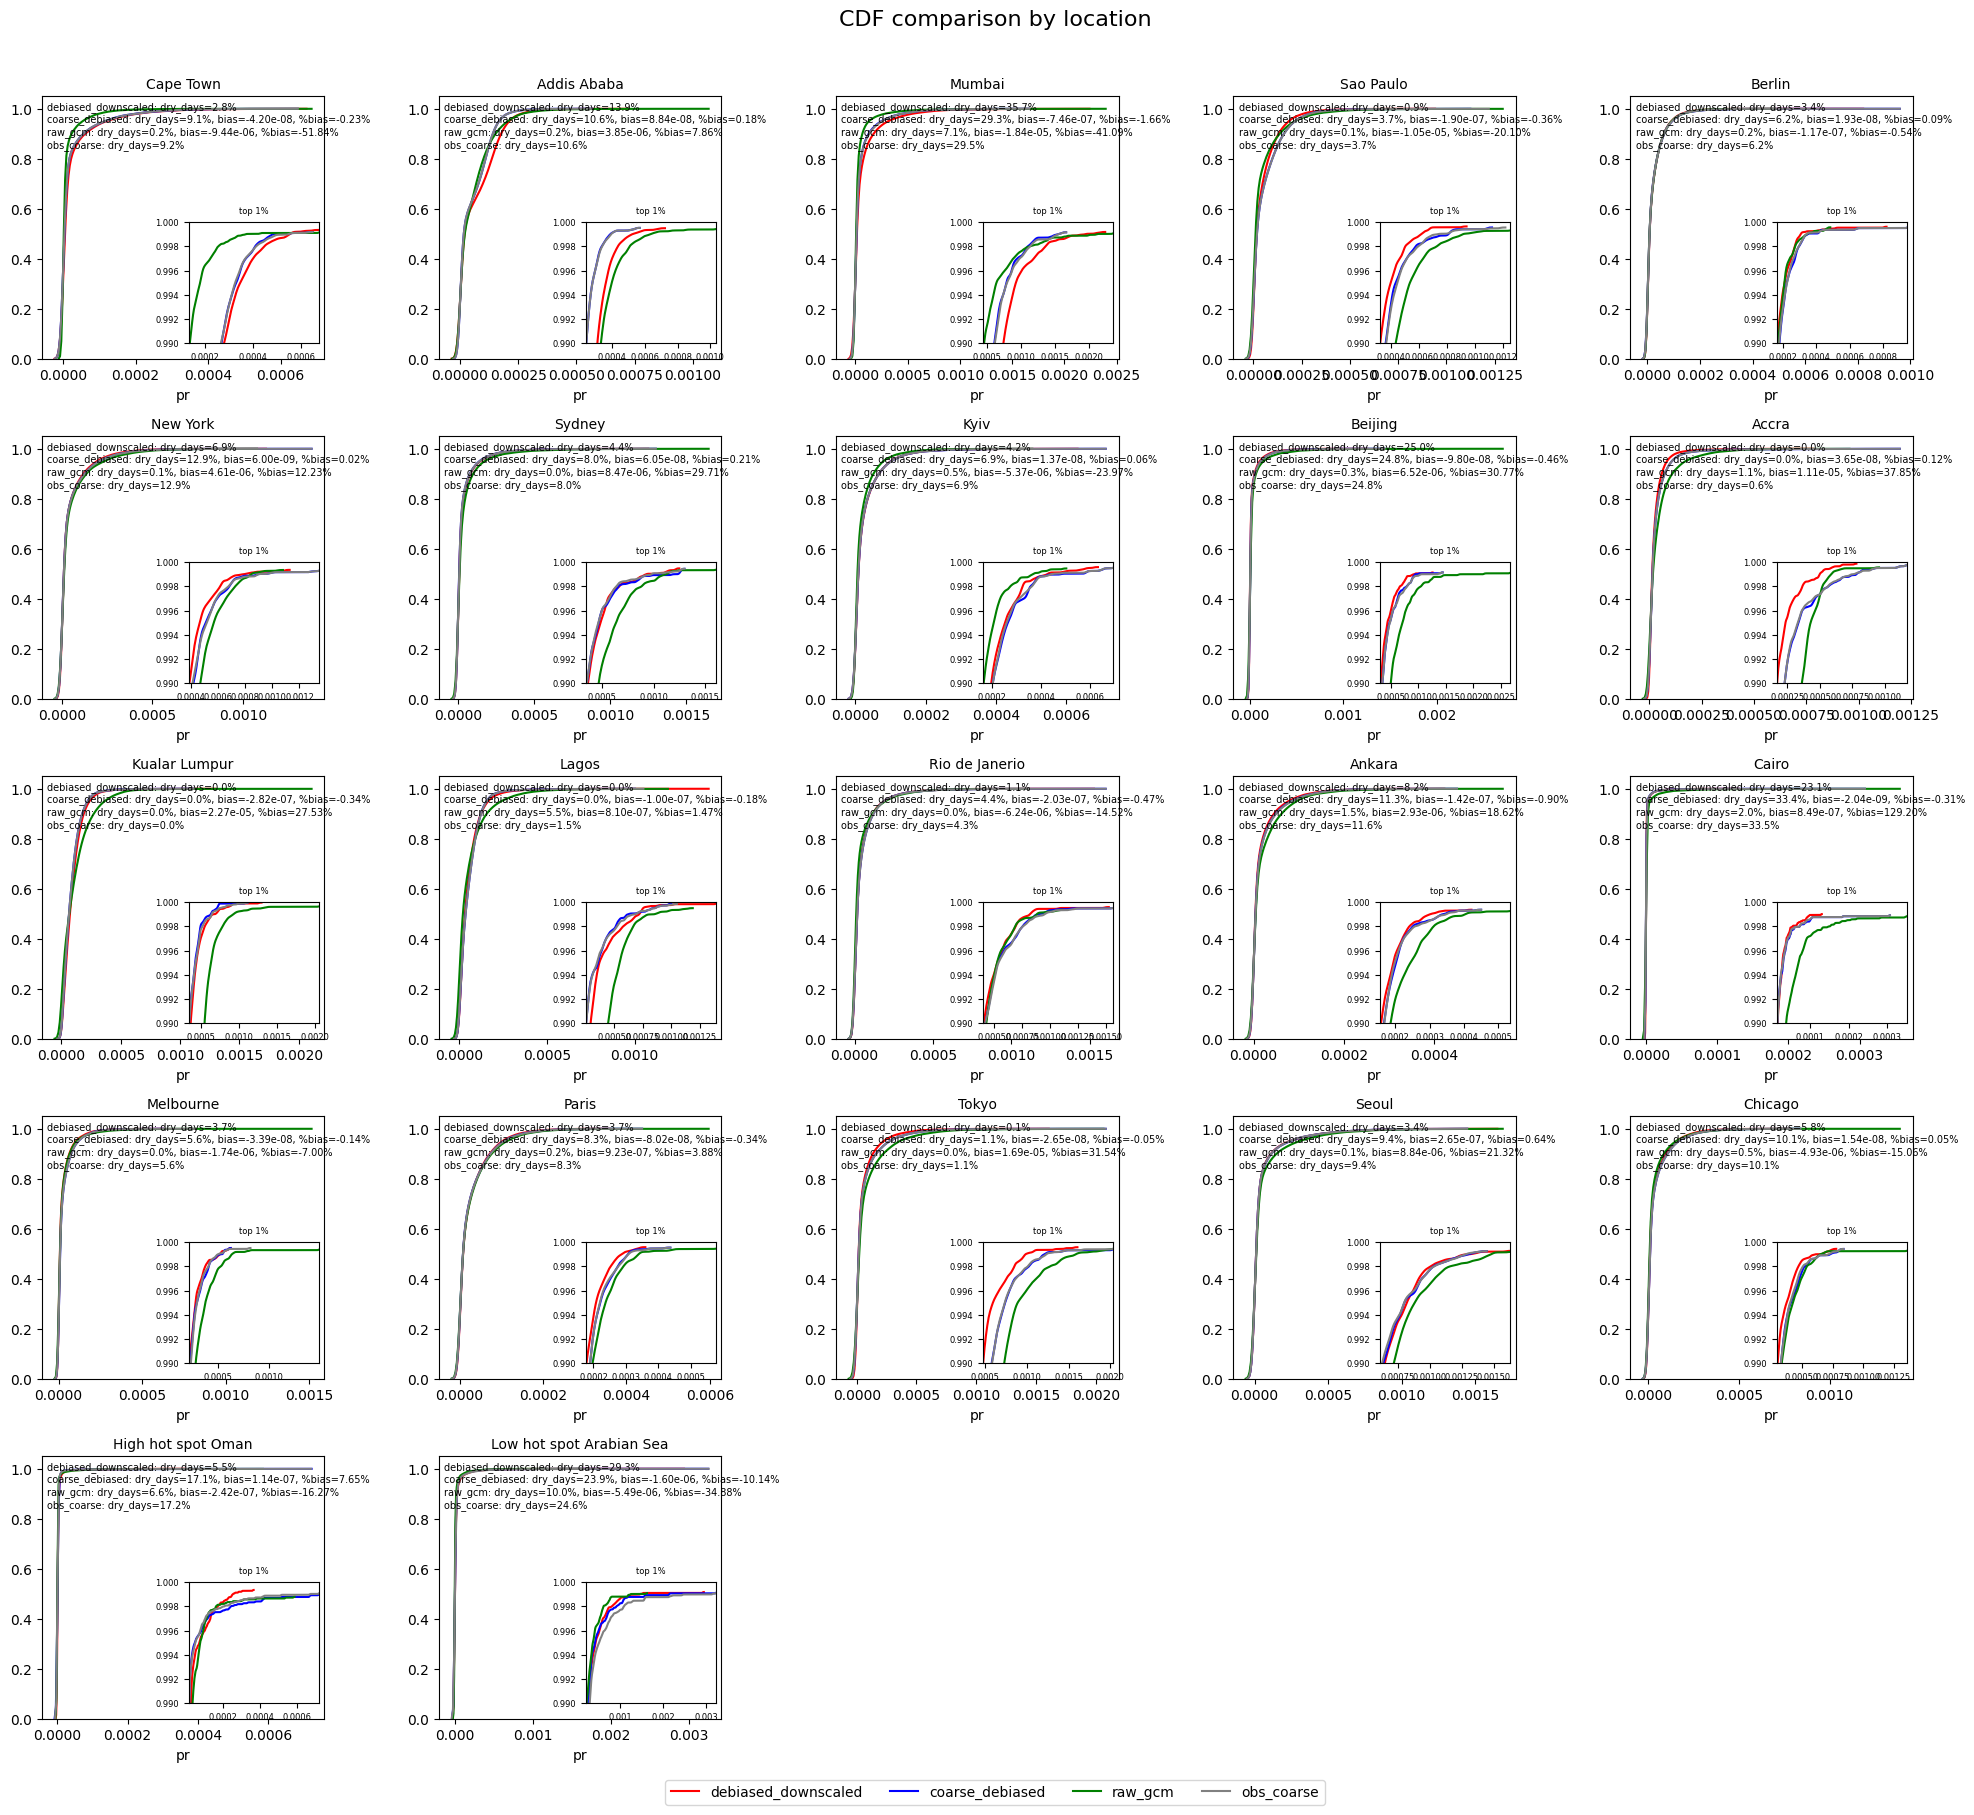

In [72]:
fig = plot_cdf_by_location(
    debiased_downscaled=debiased_downscaled,
    coarse_debiased=coarse_debiased,
    obs_coarse=obs_coarse,
    raw_gcm=raw,
    locations=locations,
    var=var)

# High bias hot spot Oman

In [15]:
(lat, lon) = locations['High hot spot Oman']

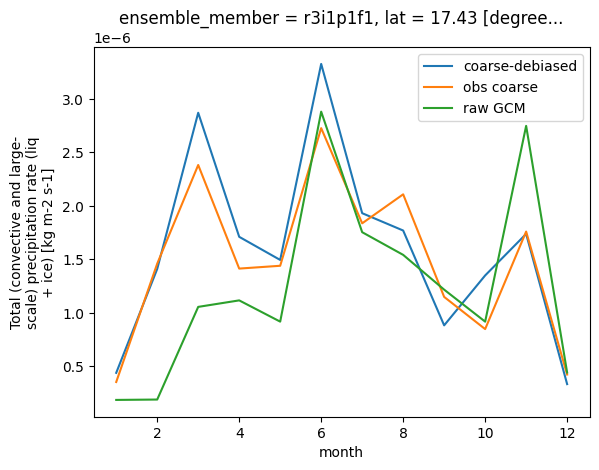

In [41]:
coarse_debiased.sel(lat=lat, lon=lon, method='nearest').groupby('time.month').mean().plot(label='coarse-debiased')
obs_coarse.sel(lat=lat, lon=lon, method='nearest').groupby('time.month').mean().plot(label='obs coarse')
raw.sel(lat=lat, lon=lon, method='nearest').groupby('time.month').mean().plot(label='raw GCM')
plt.legend()


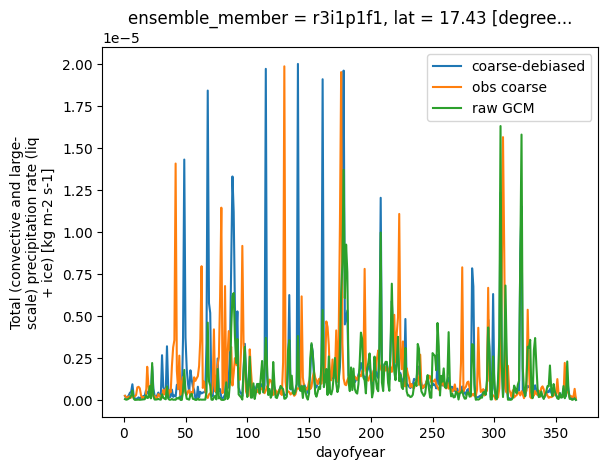

In [42]:
coarse_debiased.sel(lat=lat, lon=lon, method='nearest').groupby('time.dayofyear').mean().plot(label='coarse-debiased')
obs_coarse.sel(lat=lat, lon=lon, method='nearest').groupby('time.dayofyear').mean().plot(label='obs coarse')
raw.sel(lat=lat, lon=lon, method='nearest').groupby('time.dayofyear').mean().plot(label='raw GCM')

plt.legend()


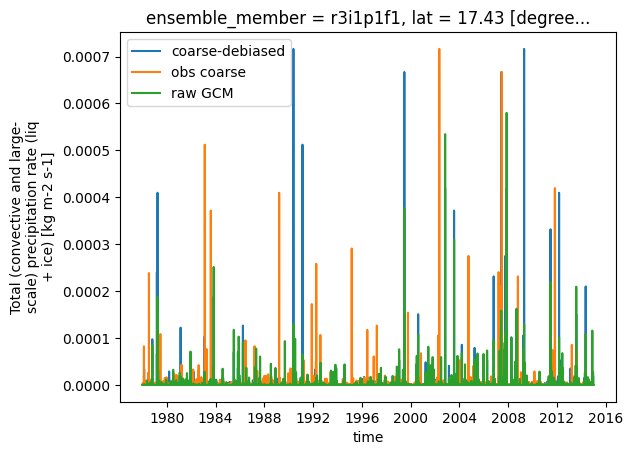

In [43]:
coarse_debiased.sel(lat=lat, lon=lon, method='nearest').plot(label='coarse-debiased')

obs_coarse.sel(lat=lat, lon=lon, method='nearest').plot(label='obs coarse')
raw.sel(lat=lat, lon=lon, method='nearest').plot(label='raw GCM')

plt.legend()


In [46]:
(coarse_debiased.sel(lat=lat, lon=lon, method='nearest').mean()/obs_coarse.sel(lat=lat, lon=lon, method='nearest').mean()).values

array(1.0765393, dtype=float32)

In [ ]:
# Low bias hot spot Arabian Sea

In [ ]:
# I think this is a result of the maximum factor that we're allowed to 

In [62]:
(lat, lon) = locations['Low hot spot Arabian Sea']

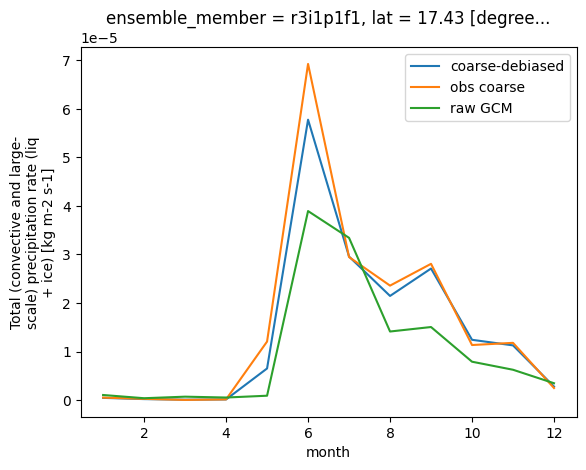

In [63]:
coarse_debiased.sel(lat=lat, lon=lon, method='nearest').groupby('time.month').mean().plot(label='coarse-debiased')
obs_coarse.sel(lat=lat, lon=lon, method='nearest').groupby('time.month').mean().plot(label='obs coarse')
raw.sel(lat=lat, lon=lon, method='nearest').groupby('time.month').mean().plot(label='raw GCM')
plt.legend()


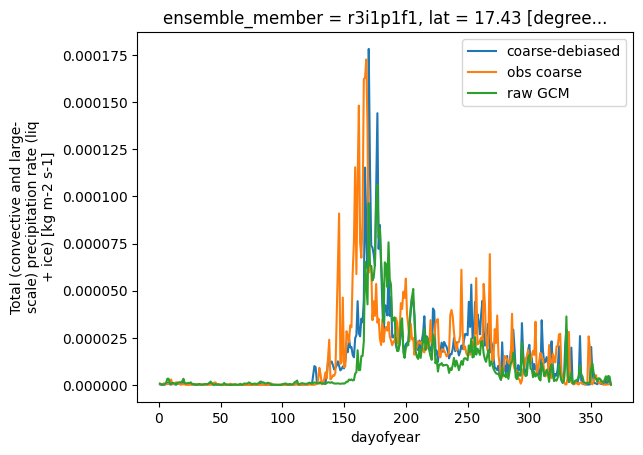

In [64]:
coarse_debiased.sel(lat=lat, lon=lon, method='nearest').groupby('time.dayofyear').mean().plot(label='coarse-debiased')
obs_coarse.sel(lat=lat, lon=lon, method='nearest').groupby('time.dayofyear').mean().plot(label='obs coarse')
raw.sel(lat=lat, lon=lon, method='nearest').groupby('time.dayofyear').mean().plot(label='raw GCM')

plt.legend()


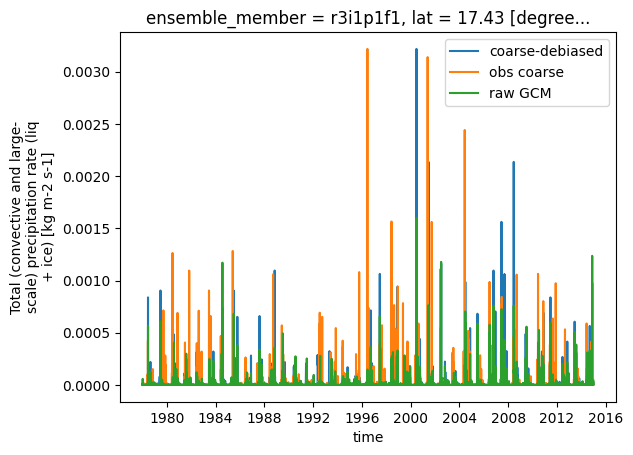

In [65]:
coarse_debiased.sel(lat=lat, lon=lon, method='nearest').plot(label='coarse-debiased')

obs_coarse.sel(lat=lat, lon=lon, method='nearest').plot(label='obs coarse')
raw.sel(lat=lat, lon=lon, method='nearest').plot(label='raw GCM')

plt.legend()
